In [1]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

# models = list_models('vllm') + ['siglip2_so400_16_512']
models = list_models('vllm')

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs', download_all_precomputed=False)

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("capability")
results["capability"] = results["benchmark_name"].map(benchmark_mappings)
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)
benchmark_mappings = get_benchmark_mappings("num_classes")
results["num_classes"] = results["benchmark_name"].map(benchmark_mappings)

results = results[(results['task_name'] == 'multi_choice_classification') | (results['task_name'] == 'multi_choice_relation')]

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/caltech101.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cars.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar10.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar100.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_count.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_distance.f
File not found:  /home/haltahan6/unibench/outpu

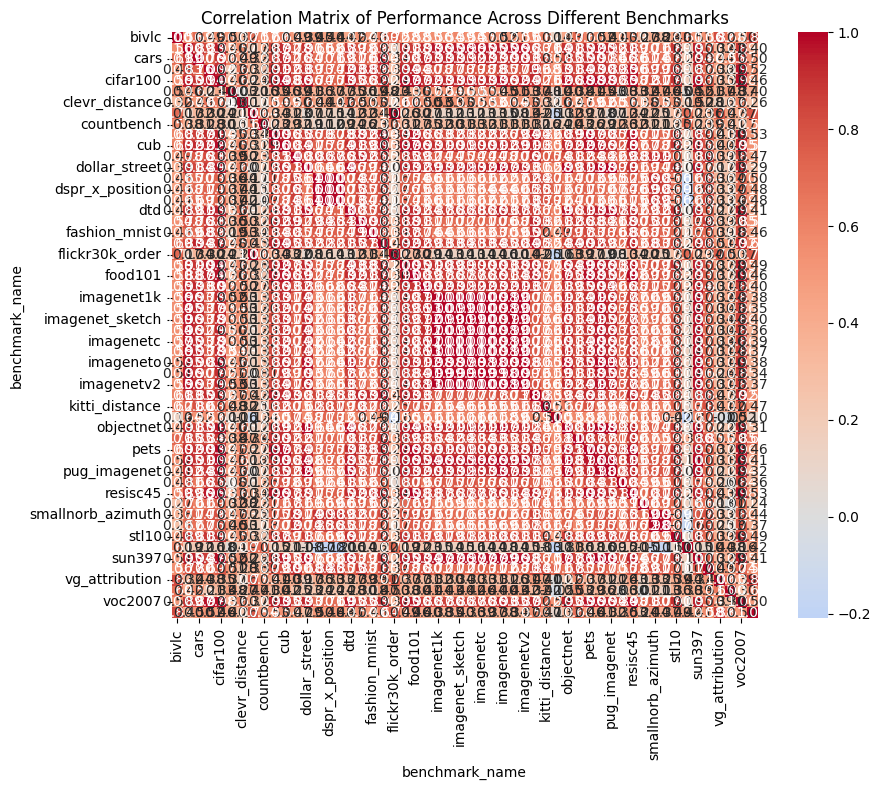

In [2]:
# Calculate mean performance by model and benchmark
performance_by_benchmark = results.groupby(['model_name', 'benchmark_name'])['correctness'].mean().reset_index()

# Pivot to create a matrix with models as rows and benchmarks as columns
benchmark_matrix = performance_by_benchmark.pivot(index='model_name', columns='benchmark_name', values='correctness')

# Create correlation matrix
correlation_matrix = benchmark_matrix.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Correlation Matrix of Performance Across Different Benchmarks')
plt.tight_layout()
plt.show()

In [3]:
# Calculate mean correlation for each benchmark (excluding self-correlation)
mean_correlations_benchmarks = benchmark_matrix.corr().apply(lambda row: row[row.index != row.name].mean(), axis=1)

# Find the benchmark with highest average correlation
most_correlated_benchmark = mean_correlations_benchmarks.idxmax()

print(f"Benchmark with highest average correlation: {most_correlated_benchmark}")
print(f"Average correlation value: {mean_correlations_benchmarks.max():.3f}")

# Get correlation matrix from cell 1
benchmark_corr_matrix = benchmark_matrix.corr()

# For each benchmark type, find the most correlated benchmark within that type
benchmark_type_analysis = []

for benchmark_type in results['benchmark_type'].unique():
    # Get benchmarks of this type
    benchmarks_of_type = results[results['benchmark_type'] == benchmark_type]['benchmark_name'].unique()
    
    # Find the benchmark in this type with highest average correlation with other benchmarks in the same type
    max_corr = -1
    most_corr_benchmark = None
    
    for benchmark in benchmarks_of_type:
        if benchmark in benchmark_corr_matrix.index:
            # Calculate average correlation with other benchmarks in the same type
            correlations_within_type = []
            for other_benchmark in benchmarks_of_type:
                if other_benchmark != benchmark and other_benchmark in benchmark_corr_matrix.columns:
                    corr_value = benchmark_corr_matrix.loc[benchmark, other_benchmark]
                    correlations_within_type.append(corr_value)
            
            if correlations_within_type:
                avg_corr = sum(correlations_within_type) / len(correlations_within_type)
                if avg_corr > max_corr:
                    max_corr = avg_corr
                    most_corr_benchmark = benchmark
    
    if most_corr_benchmark is not None:
        benchmark_type_analysis.append({
            'Benchmark Type': benchmark_type,
            'Most Correlated Benchmark': most_corr_benchmark,
            'Correlation Value': max_corr
        })

# Create DataFrame and sort by correlation value
correlation_table = pd.DataFrame(benchmark_type_analysis)
correlation_table = correlation_table.sort_values('Correlation Value', ascending=False)

# Format for LaTeX table
print("\nLaTeX Table Format:")
print("Benchmark Type & Most Correlated Benchmark & Correlation Value \\\\")
print("\\hline")
for _, row in correlation_table.iterrows():
    print(f"{row['Benchmark Type']} & {row['Most Correlated Benchmark']} & {row['Correlation Value']:.3f} \\\\")

# Display the table
print("\nTable:")
print(correlation_table.to_string(index=False, float_format='%.3f'))

Benchmark with highest average correlation: cifar100
Average correlation value: 0.794



LaTeX Table Format:
Benchmark Type & Most Correlated Benchmark & Correlation Value \\
\hline
robustness & imagenetv2 & 0.979 \\
object recognition & cifar100 & 0.916 \\
non-natural images & resisc45 & 0.841 \\
reasoning (spatial) & dspr_x_position & 0.839 \\
relation & flickr30k_order & 0.742 \\
reasoning (counting) & clevr_count & 0.157 \\

Table:
      Benchmark Type Most Correlated Benchmark  Correlation Value
          robustness                imagenetv2              0.979
  object recognition                  cifar100              0.916
  non-natural images                  resisc45              0.841
 reasoning (spatial)           dspr_x_position              0.839
            relation           flickr30k_order              0.742
reasoning (counting)               clevr_count              0.157


In [ ]:
# Calculate mean correlation for each benchmark (excluding self-correlation)
mean_correlations_benchmarks = benchmark_matrix.corr().apply(lambda row: row[row.index != row.name].mean(), axis=1)

# Find the benchmark with highest average correlation
most_correlated_benchmark = mean_correlations_benchmarks.idxmax()

print(f"Benchmark with highest average correlation: {most_correlated_benchmark}")
print(f"Average correlation value: {mean_correlations_benchmarks.max():.3f}")

# Get correlation matrix from cell 1
benchmark_corr_matrix = benchmark_matrix.corr()

# For each benchmark type, find the most correlated benchmark within that type
benchmark_type_analysis = []

for benchmark_type in results['benchmark_type'].unique():
    # Get benchmarks of this type
    benchmarks_of_type = results[results['benchmark_type'] == benchmark_type]['benchmark_name'].unique()
    
    # Find the benchmark in this type with highest average correlation with other benchmarks in the same type
    max_corr = -1
    most_corr_benchmark = None
    
    for benchmark in benchmarks_of_type:
        if benchmark in benchmark_corr_matrix.index:
            # Calculate average correlation with other benchmarks in the same type
            correlations_within_type = []
            for other_benchmark in benchmarks_of_type:
                if other_benchmark != benchmark and other_benchmark in benchmark_corr_matrix.columns:
                    corr_value = benchmark_corr_matrix.loc[benchmark, other_benchmark]
                    correlations_within_type.append(corr_value)
            
            if correlations_within_type:
                avg_corr = sum(correlations_within_type) / len(correlations_within_type)
                if avg_corr > max_corr:
                    max_corr = avg_corr
                    most_corr_benchmark = benchmark
    
    if most_corr_benchmark is not None:
        benchmark_type_analysis.append({
            'Benchmark Type': benchmark_type,
            'Most Correlated Benchmark': most_corr_benchmark,
            'Correlation Value': max_corr
        })

# Create DataFrame and sort by correlation value
correlation_table = pd.DataFrame(benchmark_type_analysis)
correlation_table = correlation_table.sort_values('Correlation Value', ascending=False)

# Format for LaTeX table
print("\nLaTeX Table Format:")
print("Benchmark Type & Most Correlated Benchmark & Correlation Value \\\\")
print("\\hline")
for _, row in correlation_table.iterrows():
    print(f"{row['Benchmark Type']} & {row['Most Correlated Benchmark']} & {row['Correlation Value']:.3f} \\\\")

# Display the table
print("\nTable:")
print(correlation_table.to_string(index=False, float_format='%.3f'))

Benchmark with highest average correlation: cifar100
Average correlation value: 0.794

LaTeX Table Format:
Benchmark Type & Most Correlated Benchmark & Correlation Value \\
\hline
texture & cifar100 & 0.951 \\
robustness & cifar100 & 0.942 \\
corruption & cifar100 & 0.926 \\
object recognition & cifar100 & 0.916 \\
non-natural images & cifar100 & 0.882 \\
reasoning & cifar100 & 0.674 \\
relation & cifar100 & 0.337 \\

Table:
    Benchmark Type Most Correlated Benchmark  Correlation Value
           texture                  cifar100              0.951
        robustness                  cifar100              0.942
        corruption                  cifar100              0.926
object recognition                  cifar100              0.916
non-natural images                  cifar100              0.882
         reasoning                  cifar100              0.674
          relation                  cifar100              0.337


In [6]:
benchmarks_of_type

array(['imagenetc'], dtype=object)

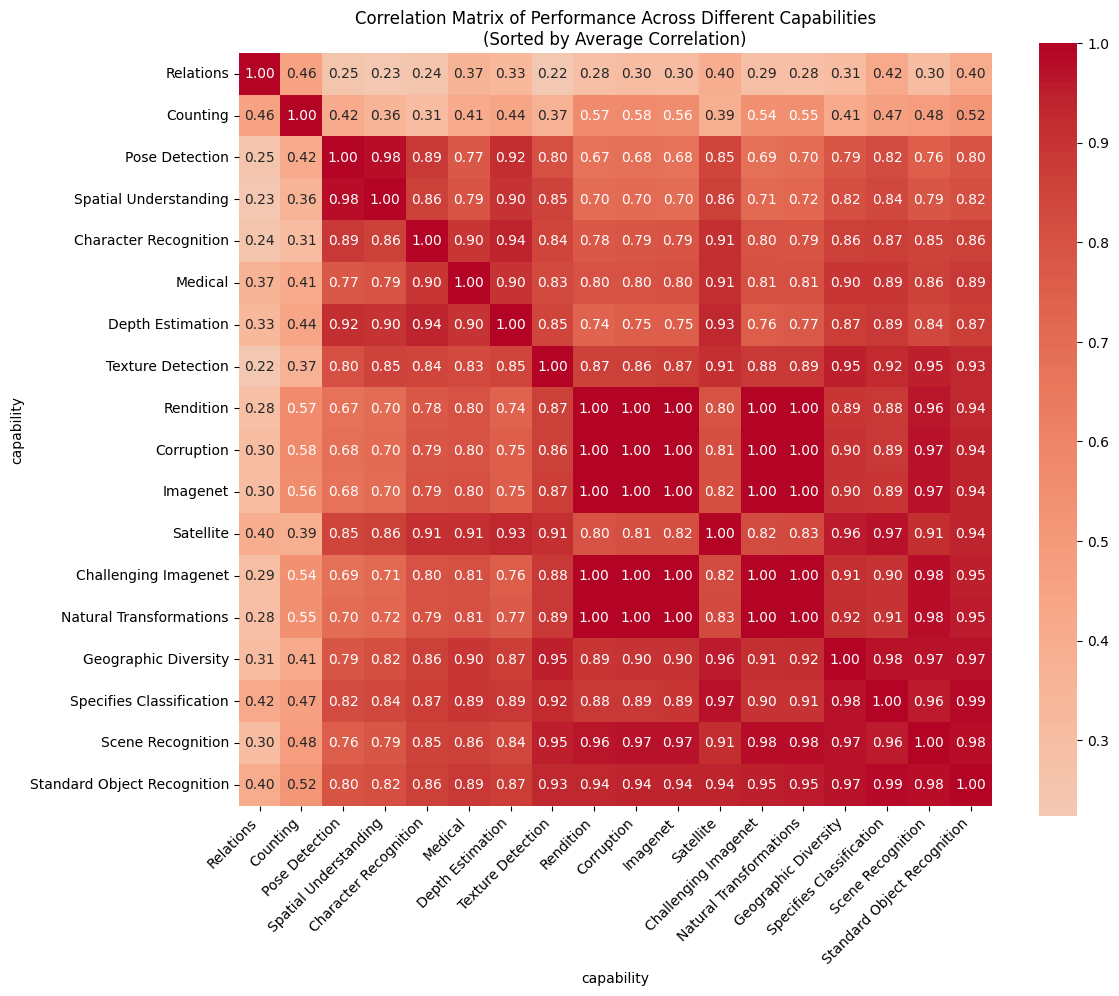

Capabilities sorted by average correlation (least to most):
 1. Relations                      0.317
 2. Counting                       0.461
 3. Pose Detection                 0.733
 4. Spatial Understanding          0.742
 5. Character Recognition          0.782
 6. Medical                        0.790
 7. Depth Estimation               0.791
 8. Texture Detection              0.812
 9. Rendition                      0.816
10. Corruption                     0.821
11. Imagenet                       0.821
12. Satellite                      0.824
13. Challenging Imagenet           0.825
14. Natural Transformations        0.829
15. Geographic Diversity           0.841
16. Specifies Classification       0.851
17. Scene Recognition              0.853
18. Standard Object Recognition    0.864


In [ ]:
# Calculate mean correlation for each capability (excluding self-correlation)
mean_correlations = correlation_matrix.apply(lambda row: row[row.index != row.name].mean(), axis=1)

# Sort from least to most average correlation
sorted_capabilities = mean_correlations.sort_values()

# Reorder the correlation matrix
correlation_matrix_sorted = correlation_matrix.loc[sorted_capabilities.index, sorted_capabilities.index]

# Plot the sorted correlation matrix with capitalized labels
plt.figure(figsize=(12, 10))
ax = sns.heatmap(correlation_matrix_sorted, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')

# Capitalize the tick labels
ax.set_xticklabels([label.get_text().title() for label in ax.get_xticklabels()], rotation=45, ha='right')
ax.set_yticklabels([label.get_text().title() for label in ax.get_yticklabels()], rotation=0)

plt.title('Correlation Matrix of Performance Across Different Capabilities\n(Sorted by Average Correlation)')
plt.tight_layout()
plt.show()

# Print the capabilities sorted by average correlation
print("Capabilities sorted by average correlation (least to most):")
for i, (capability, avg_corr) in enumerate(sorted_capabilities.items()):
    print(f"{i+1:2d}. {capability.title():<30} {avg_corr:.3f}")

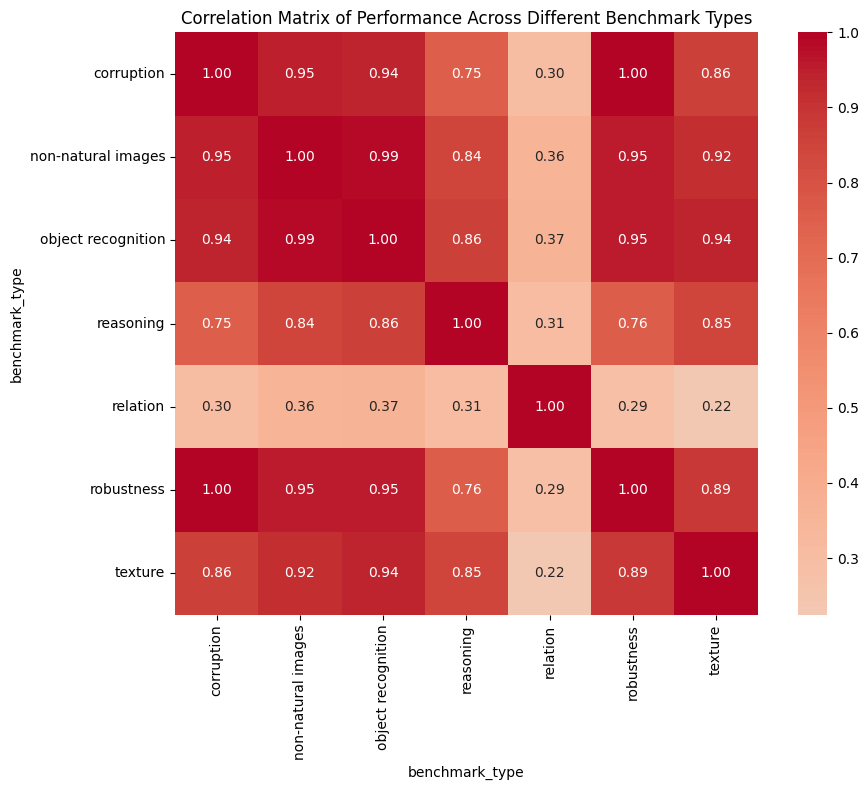

In [7]:
# Calculate mean performance by model and capability
performance_by_capability = results.groupby(['model_name', 'benchmark_type'])['correctness'].mean().reset_index()

# Pivot to create a matrix with models as rows and capabilities as columns
capability_matrix = performance_by_capability.pivot(index='model_name', columns='benchmark_type', values='correctness')

# Create correlation matrix
correlation_matrix = capability_matrix.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Correlation Matrix of Performance Across Different Benchmark Types')
plt.tight_layout()
plt.show()

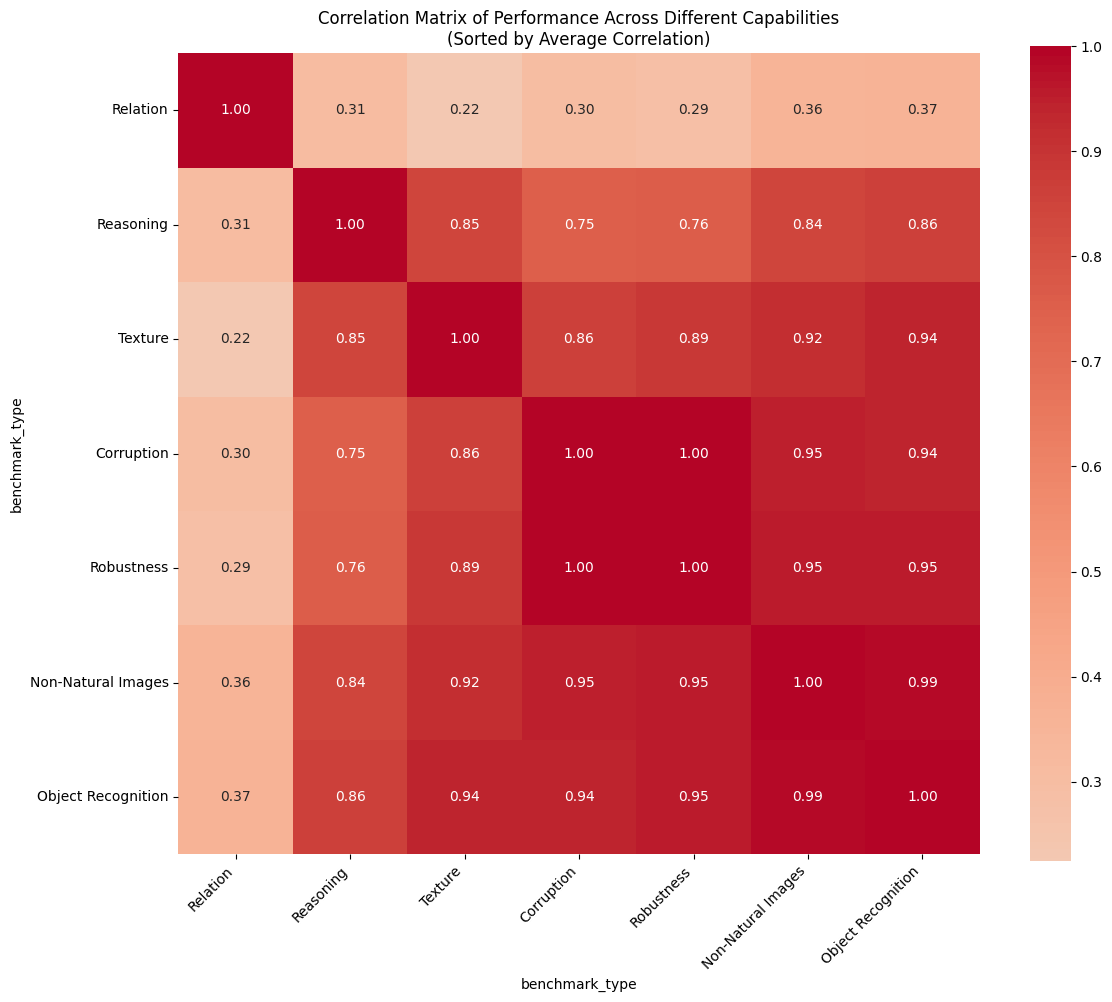

Capabilities sorted by average correlation (least to most):
 1. Relation                       0.309
 2. Reasoning                      0.731
 3. Texture                        0.780
 4. Corruption                     0.801
 5. Robustness                     0.807
 6. Non-Natural Images             0.834
 7. Object Recognition             0.842


In [8]:
# Calculate mean correlation for each capability (excluding self-correlation)
mean_correlations = correlation_matrix.apply(lambda row: row[row.index != row.name].mean(), axis=1)

# Sort from least to most average correlation
sorted_capabilities = mean_correlations.sort_values()

# Reorder the correlation matrix
correlation_matrix_sorted = correlation_matrix.loc[sorted_capabilities.index, sorted_capabilities.index]

# Plot the sorted correlation matrix with capitalized labels
plt.figure(figsize=(12, 10))
ax = sns.heatmap(correlation_matrix_sorted, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')

# Capitalize the tick labels
ax.set_xticklabels([label.get_text().title() for label in ax.get_xticklabels()], rotation=45, ha='right')
ax.set_yticklabels([label.get_text().title() for label in ax.get_yticklabels()], rotation=0)

plt.title('Correlation Matrix of Performance Across Different Capabilities\n(Sorted by Average Correlation)')
plt.tight_layout()
plt.show()

# Print the capabilities sorted by average correlation
print("Capabilities sorted by average correlation (least to most):")
for i, (capability, avg_corr) in enumerate(sorted_capabilities.items()):
    print(f"{i+1:2d}. {capability.title():<30} {avg_corr:.3f}")

In [ ]:
import os
import glob

# Get all CSV files in the directory
csv_files = glob.glob('/home/haltahan6/unibench/figures/validation_results/*.csv')

# Read and concatenate all CSV files
validation_dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    validation_dfs.append(df)

# Merge all dataframes into one
validation_results = pd.concat(validation_dfs, ignore_index=True)

print(f"Loaded {len(csv_files)} CSV files")
print(f"Combined dataframe shape: {validation_results.shape}")
print(validation_results.head())